In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(
    r"C:\Users\SudarshanMallea\Desktop\Ecommerce-Analytics-project\Dataset\Sample - Superstore.csv.csv",
    encoding="cp1252"
)

df["Order Date"] = pd.to_datetime(df["Order Date"])

In [ ]:
#Creating KPI variables
total_sales = round(df["Sales"].sum(),0)
total_profit = round(df["Profit"].sum(),0)
total_orders = df["Order ID"].nunique()
total_customers = df["Customer ID"].nunique()

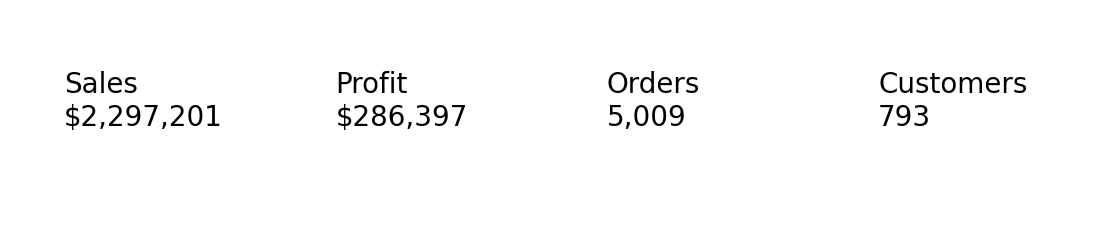

In [3]:
#Create Executive KPI Dashboard
fig, ax = plt.subplots(figsize=(14,3))

ax.axis("off")

plt.text(0.05,0.5,f"Sales\n${total_sales:,.0f}",fontsize=20)
plt.text(0.30,0.5,f"Profit\n${total_profit:,.0f}",fontsize=20)
plt.text(0.55,0.5,f"Orders\n{total_orders:,}",fontsize=20)
plt.text(0.80,0.5,f"Customers\n{total_customers:,}",fontsize=20)

plt.show()

In [5]:
#combine KPIs + Charts into one professional dashboard.
category_sales = df.groupby("Category")["Sales"].sum()

region_sales = df.groupby("Region")["Sales"].sum()

monthly_sales = (
    df.groupby(df["Order Date"].dt.month)["Sales"]
    .sum()
)

In [12]:
month_order = [
    "January","February","March","April",
    "May","June","July","August",
    "September","October","November","December"
]

monthly_sales = (
    df.groupby(df["Order Date"].dt.month_name())["Sales"]
    .sum()
    .reindex(month_order)
)

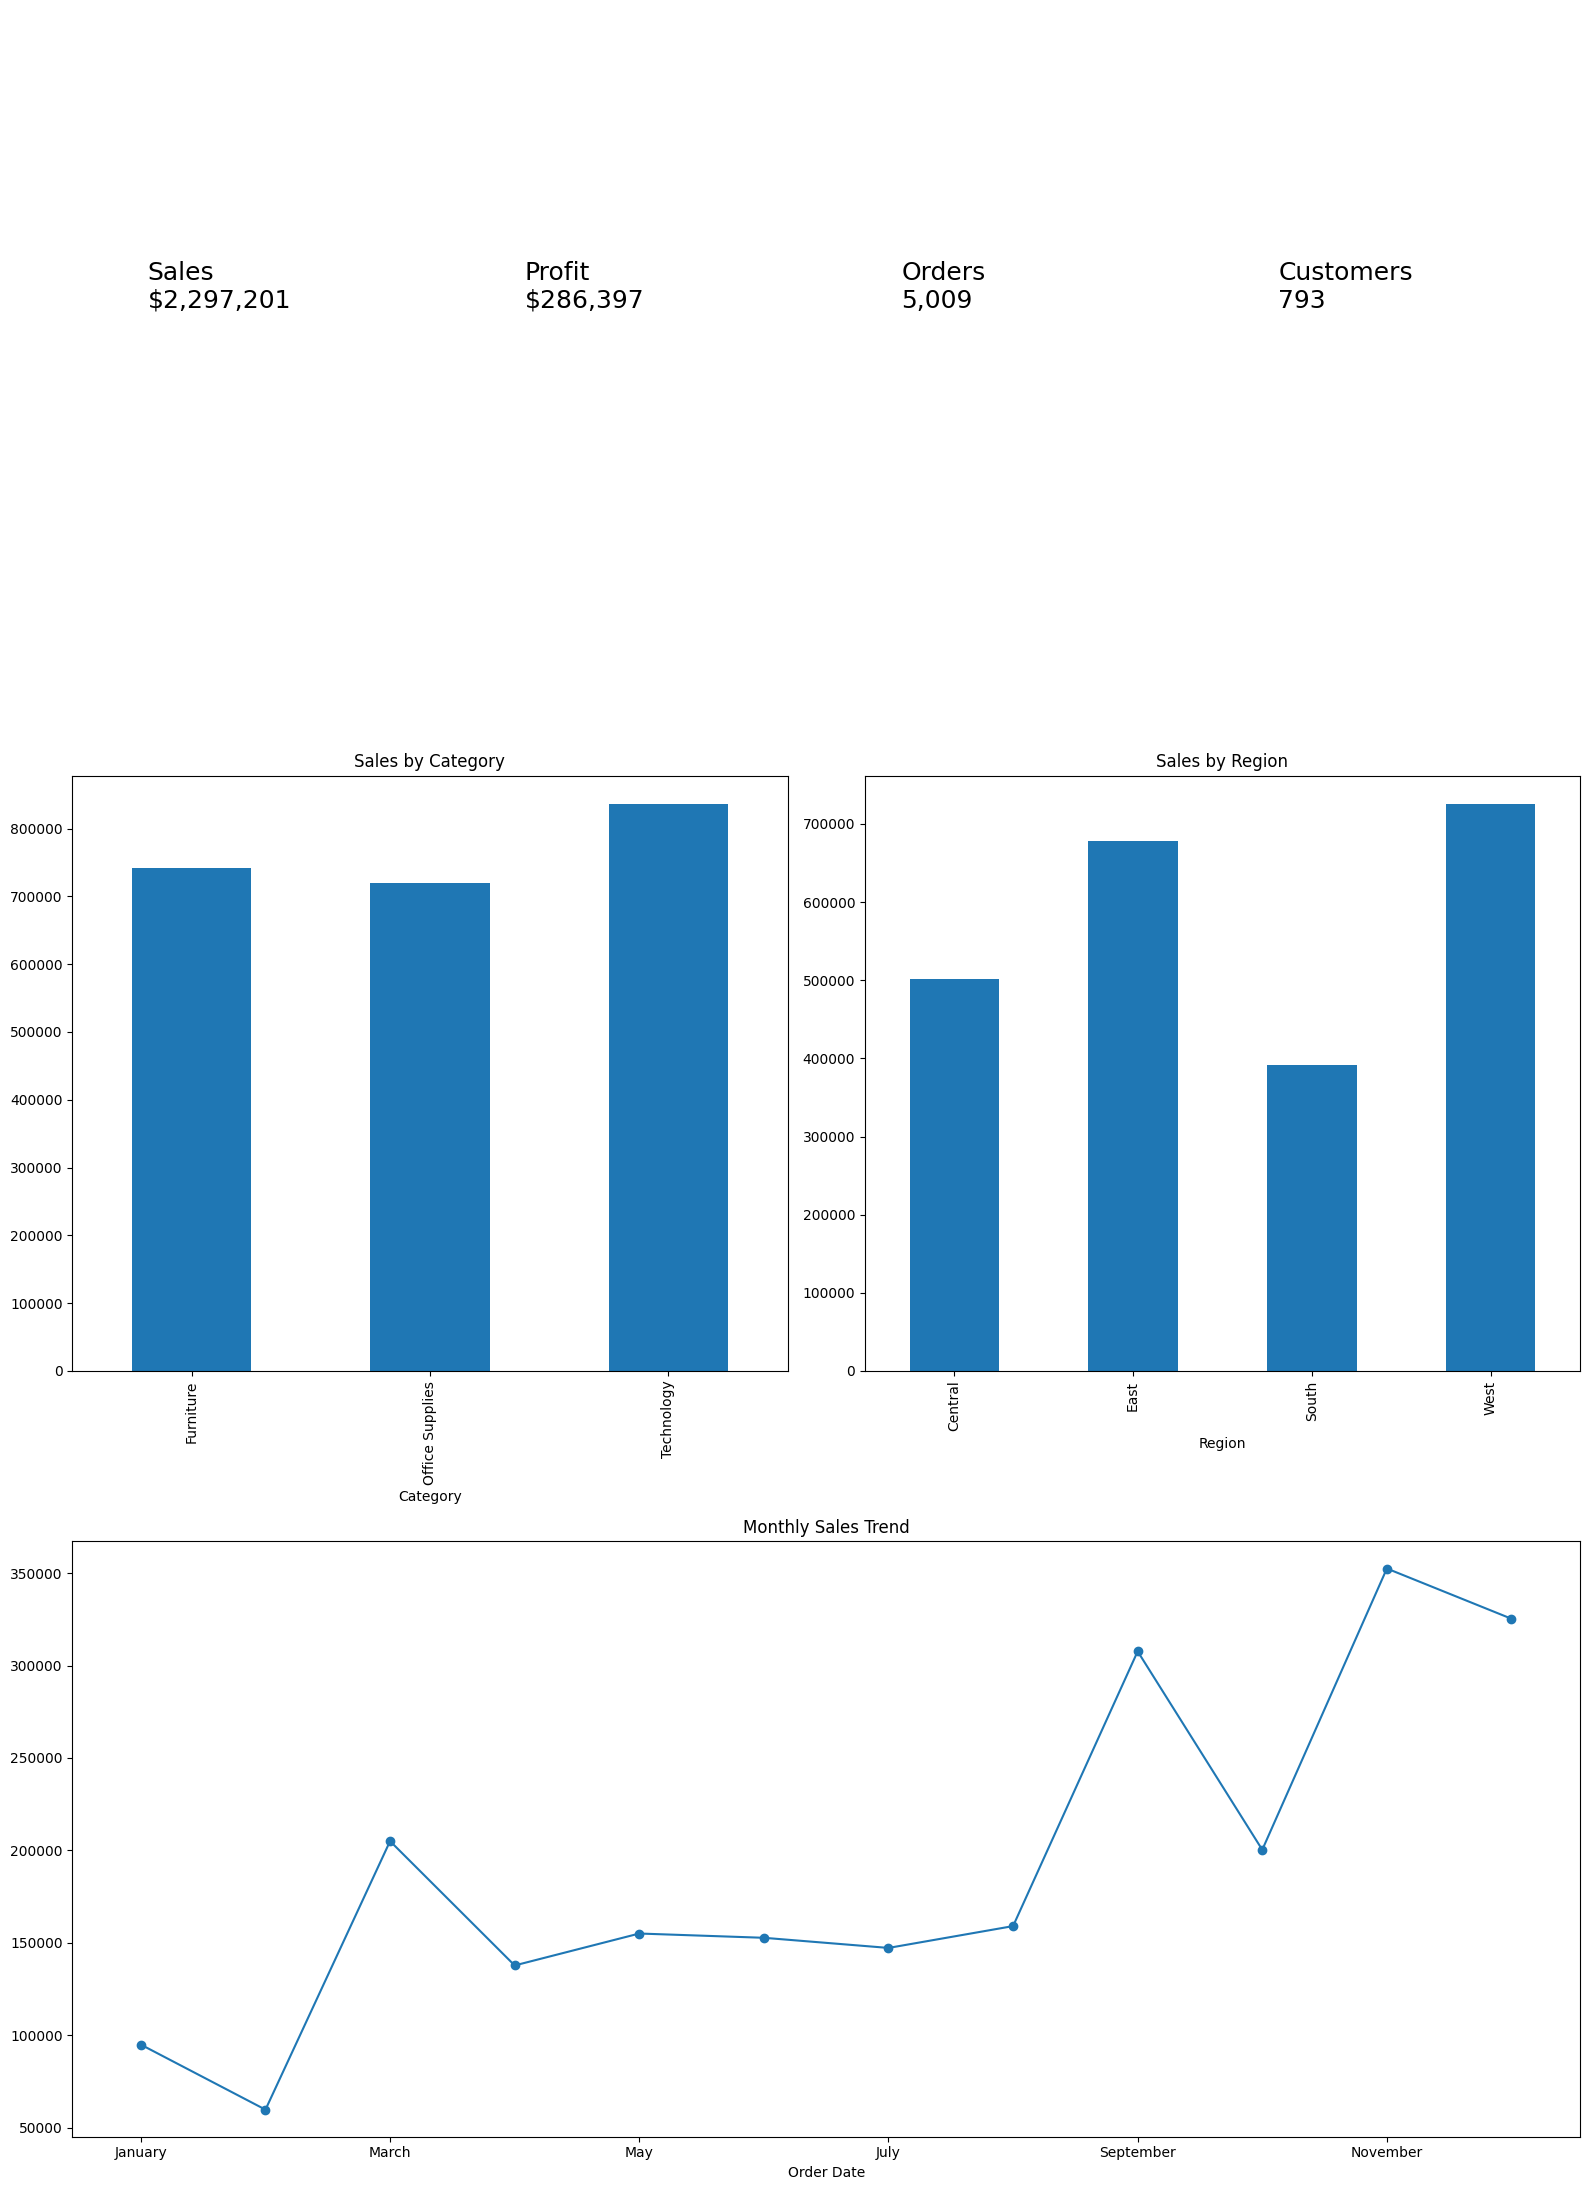

In [13]:
fig = plt.figure(figsize=(16,22))

# ---------------- KPI Row ----------------

ax1 = plt.subplot2grid((3,2),(0,0), colspan=2)
ax1.axis("off")

ax1.text(0.05,0.5,f"Sales\n${total_sales:,.0f}",fontsize=18)
ax1.text(0.30,0.5,f"Profit\n${total_profit:,.0f}",fontsize=18)
ax1.text(0.55,0.5,f"Orders\n{total_orders:,}",fontsize=18)
ax1.text(0.80,0.5,f"Customers\n{total_customers:,}",fontsize=18)

# ---------------- Category Sales ----------------

ax2 = plt.subplot2grid((3,2),(1,0))

category_sales.plot(
    kind="bar",
    ax=ax2
)

ax2.set_title("Sales by Category")

# ---------------- Region Sales ----------------

ax3 = plt.subplot2grid((3,2),(1,1))

region_sales.plot(
    kind="bar",
    ax=ax3
)

ax3.set_title("Sales by Region")

# ---------------- Monthly Trend ----------------

ax4 = plt.subplot2grid((3,2),(2,0), colspan=2)

monthly_sales.plot(
    marker="o",
    ax=ax4
)

ax4.set_title("Monthly Sales Trend")

plt.tight_layout()

plt.show()

In [14]:
#Profit Margin KPI
profit_margin = round(
    (df["Profit"].sum() / df["Sales"].sum()) * 100,
    2
)

print("Profit Margin:", profit_margin,"%")

Profit Margin: 12.47 %


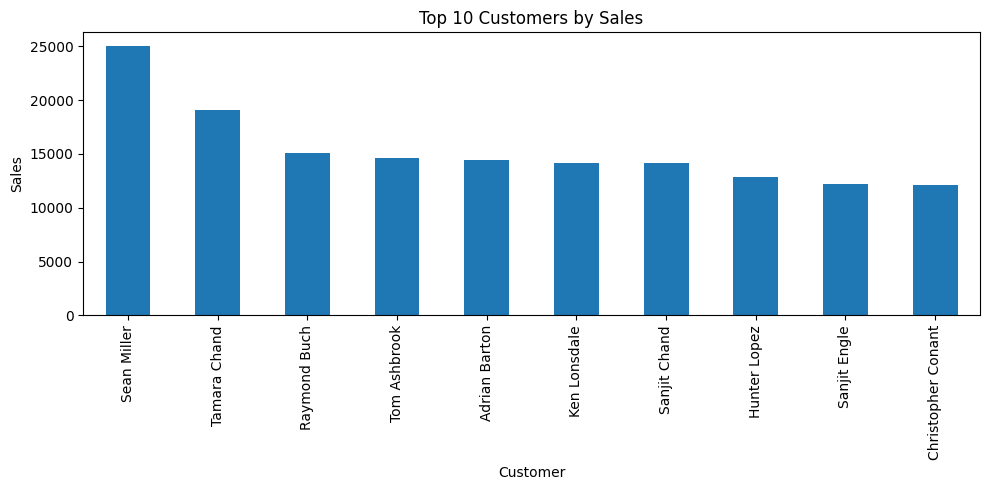

In [15]:
#Top Customers Chart
top_customers = (
    df.groupby("Customer Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))

top_customers.plot(kind="bar")

plt.title("Top 10 Customers by Sales")
plt.xlabel("Customer")
plt.ylabel("Sales")

plt.tight_layout()

plt.show()

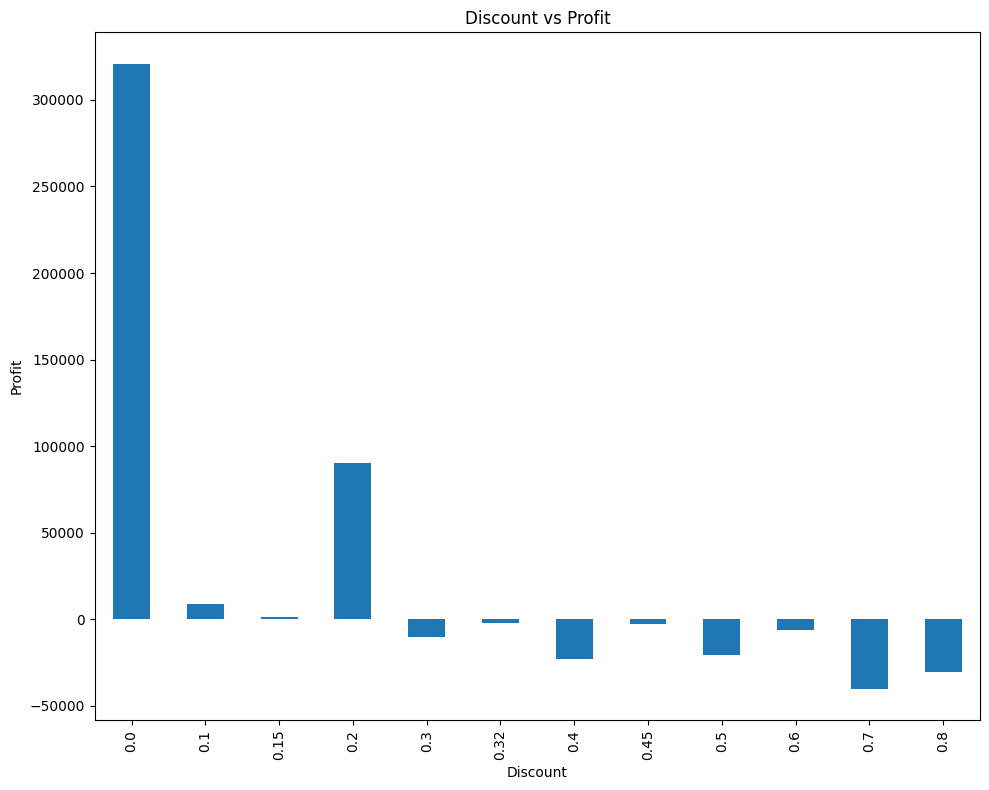

In [18]:
#Discount vs Profit Analysis
discount_profit = (
    df.groupby("Discount")["Profit"]
    .sum()
)

plt.figure(figsize=(10,8))

discount_profit.plot(
    kind="bar"
)

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.tight_layout()

plt.show()

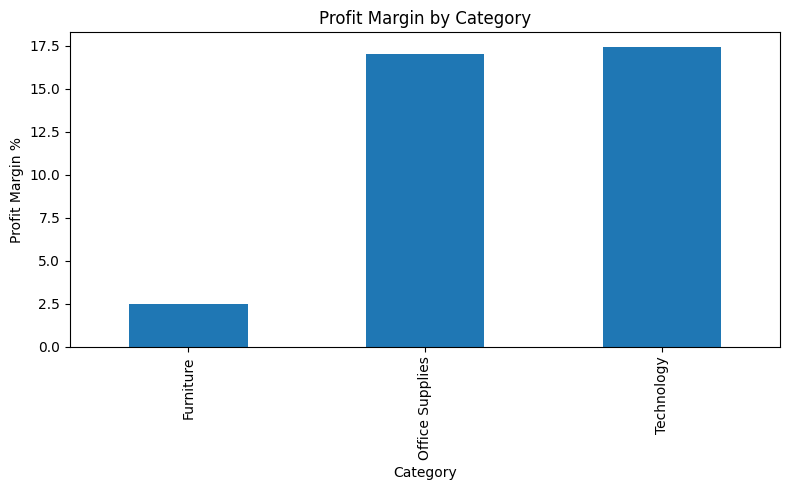

In [19]:
#Profit Margin by Category
profit_margin_category = (
    df.groupby("Category")[["Sales","Profit"]]
      .sum()
)

profit_margin_category["Profit Margin %"] = (
    profit_margin_category["Profit"]
    /
    profit_margin_category["Sales"]
) * 100

profit_margin_category["Profit Margin %"].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Profit Margin by Category")
plt.ylabel("Profit Margin %")
plt.xlabel("Category")

plt.tight_layout()
plt.show()